Loading data...
Vectorizing text... (This takes about 30-60 seconds)
Splitting data...
Training Random Forest Classifier... (Please wait)
Evaluating model...

✅ FINAL EMAIL ACCURACY: 0.9867

--- Detailed Report ---
              precision    recall  f1-score   support

        Safe       0.99      0.99      0.99      7935
    Phishing       0.99      0.99      0.99      8563

    accuracy                           0.99     16498
   macro avg       0.99      0.99      0.99     16498
weighted avg       0.99      0.99      0.99     16498

✅ Model and Vectorizer saved to 'data/processed/'!


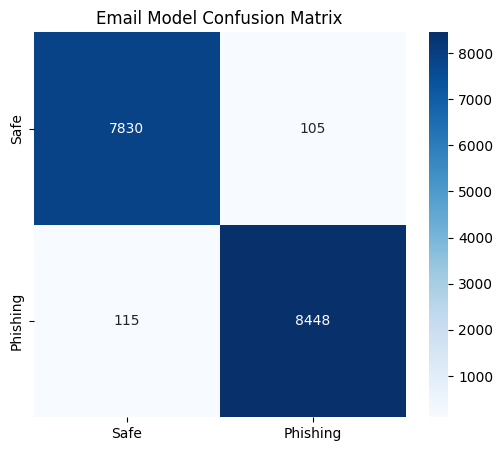

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Loading the dataset
print("Loading data...")
df = pd.read_csv('../data/raw/phishing_email.csv', on_bad_lines='skip')

# Use the correct column name we found: 'text_combined'
# Drop rows where text is missing (NaN) so the code doesn't crash
df.dropna(subset=['text_combined'], inplace=True)

# Turning words into numbers (TF-IDF)
print("Vectorizing text... (This takes about 30-60 seconds)")
# Learn the top 5,000 most important words.
# 'stop_words' removes filler like "the", "and", "is".
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['text_combined'])
y = df['label']

# Spliting Data (80% Train, 20% Test) 
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training
print("Training Random Forest Classifier... (Please wait)")
# n_jobs=-1 uses all your computer's power to go faster
email_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
email_model.fit(X_train, y_train)

# Evaluate 
print("Evaluating model...")
preds = email_model.predict(X_test)
acc = accuracy_score(y_test, preds)

print(f"\n✅ FINAL EMAIL ACCURACY: {acc:.4f}")
print("\n--- Detailed Report ---")
print(classification_report(y_test, preds, target_names=['Safe', 'Phishing']))

# Save artifacts
# Saved BOTH the model AND the vectorizer (the "dictionary")
joblib.dump(email_model, '../data/processed/email_model.joblib')
joblib.dump(vectorizer, '../data/processed/tfidf_vectorizer.joblib')
print("✅ Model and Vectorizer saved to 'data/processed/'!")

#  Vizualize since everyone loves a good confusion matrix representation 
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
plt.title('Email Model Confusion Matrix')
plt.show()